# Antarctic Grounding-Zone Velocity Anomaly

Track how ice velocity has changed inside the **grounding zone** of every Antarctic glacier from 2005 to 2025.

**Grounding zone** = the morton cells covered by the grounding line (`linestring_coverage` at HEALPix order 16, ~100 m) plus a `morton_buffer(k=5)` halo (~500 m wide ring).

**Plot 1 — annual slider.** Per-year anomaly relative to the 2000–2001 baseline (with first-valid-year fallback for cells missing in the baseline). Source: NSIDC-0720 v1 (1 km annual) → match at HEALPix order 13 (~800 m).

**Plot 2 — multi-year change.** Anomaly between the 1995–2001 and 2020–2022 multi-year reference epochs across the *master* grounding zone (union over all years). Source: NSIDC-0761 v1 (450 m multi-year) → match at HEALPix order 14 (~400 m).

Same morton-as-spatial-index pattern as the Denman notebook (`examples/morton_linestring_denman_velocity.ipynb`) — no KD-tree, no spatial bbox filters; the morton-cell key is the join.

In [1]:
from pathlib import Path
import re
import time

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import LineString, MultiLineString
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
from IPython.display import display

import earthaccess
import mortie
print('mortie', mortie.__version__)

mortie 0.4.0


## Constants and helpers

All match-and-render decisions are in one place. The two plots use different match orders because their underlying data resolutions differ (1 km vs 450 m).

In [2]:
GL_ORDER     = 16          # ~100 m grounding-line cells
BUFFER_K     = 5           # ~500 m halo around each line
PLOT1_MATCH  = 13          # ~800 m, matches 1 km NSIDC-0720 annual velocity
PLOT2_MATCH  = 14          # ~400 m, matches 450 m NSIDC-0761 multi-year velocity
PLOT2_EPOCH_BASELINE = '1995-2001'
PLOT2_EPOCH_RECENT   = '2020-2022'
BASELINE_YEAR        = 2000  # 2000-2001 map in NSIDC-0720, keyed as 2000

R_EARTH_M = 6_371_008.7714
def cell_width_m(order):
    return R_EARTH_M * np.sqrt(np.pi / 3.0) / (1 << order)
for o in (GL_ORDER, PLOT1_MATCH, PLOT2_MATCH):
    print(f'  order {o}: ~{cell_width_m(o):7.1f} m per cell side')

  order 16: ~   99.5 m per cell side
  order 13: ~  795.9 m per cell side
  order 14: ~  397.9 m per cell side


In [3]:
def morton_clip_order(morton_indices, src_order, tgt_order):
    """Clip morton indices from src_order -> tgt_order by digit truncation."""
    if tgt_order == src_order:
        return np.asarray(morton_indices, dtype=np.int64)
    if tgt_order > src_order:
        raise ValueError('tgt_order must be <= src_order')
    m = np.asarray(morton_indices, dtype=np.int64)
    factor = 10 ** (src_order - tgt_order)
    out = np.abs(m) // factor
    return np.where(m < 0, -out, out).astype(np.int64)


def shapely_to_latlon(geom):
    """LineString/MultiLineString -> (list_of_lats, list_of_lons)."""
    if isinstance(geom, LineString):
        xs, ys = np.asarray(geom.xy[0]), np.asarray(geom.xy[1])
        return [ys], [xs]
    if isinstance(geom, MultiLineString):
        las, los = [], []
        for ls in geom.geoms:
            xs, ys = np.asarray(ls.xy[0]), np.asarray(ls.xy[1])
            las.append(ys); los.append(xs)
        return las, los
    raise TypeError(type(geom).__name__)


def download_if_missing(results, local_path, ext):
    """Skip earthaccess.download entirely if every expected file is already cached."""
    local_path = Path(local_path); local_path.mkdir(exist_ok=True)
    cached, needs, skipped = [], [], 0
    for r in results:
        links = []
        for access in ('external', 'direct'):
            try:
                links = r.data_links(access=access)
            except Exception:
                links = []
            if links: break
        urls = [u for u in links if u.lower().endswith(ext)]
        if not urls:
            skipped += 1; continue
        name = Path(urls[0].split('?')[0]).name
        cand = local_path / name
        if cand.exists() and cand.stat().st_size > 0:
            cached.append(str(cand))
        else:
            needs.append(r)
    if cached: print(f'  cache hit: {len(cached)} file(s) in {local_path}')
    if skipped: print(f'  skipped {skipped} granule(s) with no *{ext} asset')
    fresh = []
    if needs:
        print(f'  downloading {len(needs)} missing granule(s)...')
        fresh = earthaccess.download(needs, local_path=str(local_path))
    return cached + list(fresh)


to_4326 = Transformer.from_crs('EPSG:3031', 'EPSG:4326', always_xy=True)

## 1. Grounding lines — NSIDC-0498 (reuse cached file)

All glaciers, all years. The geopackage is reused from `insar_gl_cache/` if already on disk.

In [4]:
auth = earthaccess.login(persist=True)

gl_cache = Path('./insar_gl_cache')
gl_results = earthaccess.search_data(short_name='NSIDC-0498', version='2')
print(f'{len(gl_results)} NSIDC-0498 granules available')
gl_files = download_if_missing(gl_results, gl_cache, ext='.gpkg')
gpkg_files = [Path(f) for f in gl_files if str(f).lower().endswith('.gpkg')]

gdfs = []
for p in sorted(gpkg_files):
    g = gpd.read_file(p)
    if g.crs and g.crs.to_epsg() != 4326:
        g = g.to_crs(4326)
    gdfs.append(g)
gdf_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs='EPSG:4326')
print(f'{len(gdf_all):,} grounding-line features total across {gdf_all["Year"].nunique()} years')
GL_YEARS = sorted(gdf_all['Year'].dropna().astype(int).unique().tolist())
print(f'years: {GL_YEARS}')

/home/espg/.conda/envs/mortie/lib/python3.13/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


2 NSIDC-0498 granules available
  cache hit: 1 file(s) in insar_gl_cache
  skipped 1 granule(s) with no *.gpkg asset
1,820 grounding-line features total across 24 years
years: [1992, 1994, 1995, 1996, 1999, 2000, 2007, 2008, 2009, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 2. Per-year grounding zones at order 16 + master union

For each year, every linestring is rasterized to order-16 cells and a k=5 morton buffer is added. The union across years gives the master zone. We keep everything at order 16 here so that Plot 1 (clip to 13) and Plot 2 (clip to 14) can re-clip independently.

In [5]:
def gz_for_year(gdf_year):
    """Compute a year's grounding zone at GL_ORDER (cells covered by lines + k buffer)."""
    lats_parts, lons_parts = [], []
    for geom in gdf_year.geometry:
        if geom is None or geom.is_empty:
            continue
        la, lo = shapely_to_latlon(geom)
        lats_parts.extend(la); lons_parts.extend(lo)
    if not lats_parts:
        return np.empty(0, np.int64)
    per_line = mortie.linestring_coverage(lats_parts, lons_parts, order=GL_ORDER)
    cells = np.unique(np.concatenate(per_line))
    if cells.size == 0:
        return cells
    ring = mortie.morton_buffer(cells, k=BUFFER_K)
    return np.union1d(cells, ring)

GZ16_BY_YEAR = {}
t0 = time.perf_counter()
for y in GL_YEARS:
    sub = gdf_all[gdf_all['Year'] == y]
    GZ16_BY_YEAR[y] = gz_for_year(sub)
    print(f'  {y}: {len(sub):4d} features -> {GZ16_BY_YEAR[y].size:>10,} order-16 cells')
print(f'total: {time.perf_counter()-t0:.1f}s')

GZ16_MASTER = np.unique(np.concatenate([c for c in GZ16_BY_YEAR.values() if c.size]))
print(f'master grounding zone (order 16): {GZ16_MASTER.size:,} cells')

  1992:   12 features ->    561,985 order-16 cells
  1994:   13 features ->    665,740 order-16 cells
  1995:   29 features ->  1,634,844 order-16 cells
  1996:  111 features ->  3,414,520 order-16 cells
  1999:    2 features ->    155,654 order-16 cells
  2000:   47 features ->    984,128 order-16 cells
  2007:   33 features ->    569,191 order-16 cells
  2008:    2 features ->     35,239 order-16 cells
  2009:   27 features ->    939,114 order-16 cells
  2011:   14 features ->    605,747 order-16 cells
  2012:    1 features ->      4,115 order-16 cells
  2013:    1 features ->     10,618 order-16 cells
  2014:    1 features ->     51,670 order-16 cells
  2015:   21 features ->    737,217 order-16 cells
  2016:  106 features ->  1,308,950 order-16 cells
  2017:  234 features ->  3,622,035 order-16 cells
  2018:  231 features ->  2,575,914 order-16 cells
  2019:  192 features ->  1,655,045 order-16 cells
  2020:  325 features ->  1,901,861 order-16 cells
  2021:   64 features ->    397

In [6]:
# Pre-clip to each plot's match order. These are the keys we'll join velocity to.
GZ_BY_YEAR_PLOT1 = {y: np.unique(morton_clip_order(c, GL_ORDER, PLOT1_MATCH))
                    for y, c in GZ16_BY_YEAR.items()}
GZ_MASTER_PLOT1  = np.unique(morton_clip_order(GZ16_MASTER, GL_ORDER, PLOT1_MATCH))
GZ_MASTER_PLOT2  = np.unique(morton_clip_order(GZ16_MASTER, GL_ORDER, PLOT2_MATCH))
print(f'master at order {PLOT1_MATCH}: {GZ_MASTER_PLOT1.size:>10,} cells')
print(f'master at order {PLOT2_MATCH}: {GZ_MASTER_PLOT2.size:>10,} cells')

master at order 13:    251,531 cells
master at order 14:    840,674 cells


## 3. NSIDC-0720 — annual ice velocity (Plot 1 source)

One file per year (plus a 2000–2001 baseline). The first-time download is large (~few hundred MB × ~21 files); subsequent re-runs hit the cache.

In [7]:
vel_annual_cache = Path('./nsidc0720_cache')
vel_annual_results = earthaccess.search_data(short_name='NSIDC-0720', version='1')
print(f'{len(vel_annual_results)} NSIDC-0720 granules available')
vel_annual_files = download_if_missing(vel_annual_results, vel_annual_cache, ext='.nc')
nc_annual = sorted([Path(f) for f in vel_annual_files if str(f).lower().endswith('.nc')])
for p in nc_annual:
    print(f'  {p.name}  ({p.stat().st_size/1e6:.1f} MB)')

21 NSIDC-0720 granules available
  cache hit: 21 file(s) in nsidc0720_cache
  Antarctica_ice_velocity_2000_2001_1km_v01.1.nc  (1380.4 MB)
  Antarctica_ice_velocity_2005_2006_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2006_2007_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2007_2008_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2008_2009_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2009_2010_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2010_2011_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2011_2012_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2012_2013_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2013_2014_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2014_2015_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2015_2016_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2016_2017_1km_v01.nc  (1380.4 MB)
  Antarctica_ice_velocity_2017_2018_1km_v01.1.nc  (1380.4 MB)
  Antarctica_ice_velocity_2018_2019_1km_v01.1.nc  (1380.4 MB)
  Antarctica_ice_v

/home/espg/.conda/envs/mortie/lib/python3.13/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [8]:
_RX = re.compile(r'(\d{4})[_-](\d{4})')
def _epoch_from_name(name):
    m = _RX.search(name)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))

def load_velocity_morton(path: Path, match_order: int, chunk_rows: int = 1024,
                        gz_filter: np.ndarray | None = None) -> dict:
    """Open a NetCDF velocity file, compute V = sqrt(VX**2 + VY**2), morton-index
    each pixel center at *match_order*, and return a {morton: speed} dict.
    
    NaN and exactly-zero speeds are dropped. If *gz_filter* is given (sorted
    array of grounding-zone morton cells at *match_order*), we drop pixels
    whose morton isn't in the filter as we go, keeping memory tiny.
    """
    ds = xr.open_dataset(path, engine='h5netcdf', chunks={})
    xname = 'x' if 'x' in ds.dims else 'X'
    yname = 'y' if 'y' in ds.dims else 'Y'
    xs_full = ds[xname].values.astype(np.float64)
    ys_full = ds[yname].values.astype(np.float64)
    
    morton_keys = []
    speed_vals = []
    for y0 in range(0, ys_full.size, chunk_rows):
        y1 = min(y0 + chunk_rows, ys_full.size)
        sub = ds.isel({yname: slice(y0, y1)})
        vx = sub['VX'].values.astype(np.float32)
        vy = sub['VY'].values.astype(np.float32)
        while vx.ndim > 2:
            vx = vx.squeeze(axis=0); vy = vy.squeeze(axis=0)
        speed = np.sqrt(vx*vx + vy*vy)
        # NaN and exactly-zero -> NA
        valid = np.isfinite(speed) & (speed > 0)
        if not valid.any():
            continue
        ys_block = ys_full[y0:y1]
        xx, yy = np.meshgrid(xs_full, ys_block)
        rr, cc = np.nonzero(valid)
        xv = xx[rr, cc]; yv = yy[rr, cc]; sv = speed[rr, cc]
        lons, lats = to_4326.transform(xv, yv)
        mort = mortie.geo2mort(np.ascontiguousarray(lats),
                               np.ascontiguousarray(lons),
                               order=match_order)
        if gz_filter is not None:
            keep = np.isin(mort, gz_filter)
            mort = mort[keep]; sv = sv[keep]
        if mort.size:
            morton_keys.append(mort)
            speed_vals.append(sv)
    ds.close()
    
    if not morton_keys:
        return {}
    mort_all = np.concatenate(morton_keys)
    sv_all = np.concatenate(speed_vals)
    # Multiple pixels can land in the same morton cell — keep the mean.
    order = np.argsort(mort_all, kind='stable')
    mort_s = mort_all[order]
    sv_s = sv_all[order]
    uniq, idx_start = np.unique(mort_s, return_index=True)
    means = np.add.reduceat(sv_s, idx_start) / np.diff(np.r_[idx_start, mort_s.size])
    return dict(zip(uniq.tolist(), means.tolist()))

In [9]:
# Process every NSIDC-0720 file -> {year: {morton@13: speed}}
VEL_ANNUAL = {}
for p in nc_annual:
    sy, ey = _epoch_from_name(p.name)
    if sy is None:
        print(f'  skip (no epoch in name): {p.name}'); continue
    t0 = time.perf_counter()
    speeds = load_velocity_morton(p, match_order=PLOT1_MATCH, gz_filter=GZ_MASTER_PLOT1)
    dt = time.perf_counter() - t0
    VEL_ANNUAL[sy] = {'speeds': speeds, 'span': (sy, ey), 'path': p}
    print(f'  {p.name}  [{sy}-{ey}]  {len(speeds):>9,} grounding-zone cells with valid V   ({dt:.1f}s)')

ANNUAL_YEARS = sorted(VEL_ANNUAL.keys())
print(f'\nannual velocity years loaded: {ANNUAL_YEARS}')

/home/espg/.local/lib/python3.13/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'h5coro' loading failed:
No module named 'boto3'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


  Antarctica_ice_velocity_2000_2001_1km_v01.1.nc  [2000-2001]     99,120 grounding-zone cells with valid V   (5.0s)
  Antarctica_ice_velocity_2005_2006_1km_v01.nc  [2005-2006]     78,127 grounding-zone cells with valid V   (2.0s)
  Antarctica_ice_velocity_2006_2007_1km_v01.nc  [2006-2007]     62,678 grounding-zone cells with valid V   (2.9s)
  Antarctica_ice_velocity_2007_2008_1km_v01.nc  [2007-2008]    122,631 grounding-zone cells with valid V   (4.5s)
  Antarctica_ice_velocity_2008_2009_1km_v01.nc  [2008-2009]    136,659 grounding-zone cells with valid V   (6.3s)
  Antarctica_ice_velocity_2009_2010_1km_v01.nc  [2009-2010]     99,820 grounding-zone cells with valid V   (3.3s)
  Antarctica_ice_velocity_2010_2011_1km_v01.nc  [2010-2011]    116,320 grounding-zone cells with valid V   (3.9s)
  Antarctica_ice_velocity_2011_2012_1km_v01.nc  [2011-2012]     18,477 grounding-zone cells with valid V   (1.1s)
  Antarctica_ice_velocity_2012_2013_1km_v01.nc  [2012-2013]     39,989 grounding-zone 

## 4. Per-cell baseline + per-year anomaly (Plot 1 payload)

Baseline rule per cell:
1. Use the 2000–2001 velocity if valid.
2. Otherwise, walk forward through the annual maps and pick the first year that has a valid velocity at that cell.
3. Cells that never have a valid velocity → NaN (excluded from the plot).

Anomaly per year `Y` per cell `c`: `velocity(Y, c) − baseline(c)`.

In [10]:
BASELINE = {}
baseline_year = BASELINE_YEAR if BASELINE_YEAR in VEL_ANNUAL else None
fallback_order = [y for y in ANNUAL_YEARS if y != BASELINE_YEAR]
for cell in GZ_MASTER_PLOT1:
    cell_int = int(cell)
    v = None
    if baseline_year is not None:
        v = VEL_ANNUAL[baseline_year]['speeds'].get(cell_int)
    if v is None:
        for yr in fallback_order:
            v = VEL_ANNUAL[yr]['speeds'].get(cell_int)
            if v is not None:
                break
    if v is not None:
        BASELINE[cell_int] = v
print(f'baseline assigned for {len(BASELINE):,} of {GZ_MASTER_PLOT1.size:,} master cells')

baseline assigned for 155,069 of 251,531 master cells


In [11]:
# Per-year anomaly: for each year (excluding the baseline year itself), keep
# only cells in that year's grounding zone where both V and BASELINE are valid.
ANOMALY_BY_YEAR = {}
for yr in ANNUAL_YEARS:
    if yr == BASELINE_YEAR:
        continue
    cells_y = GZ_BY_YEAR_PLOT1.get(yr)
    # For years with no GL features (gap years), fall back to the master GZ
    if cells_y is None or cells_y.size == 0:
        cells_y = GZ_MASTER_PLOT1
    speeds_y = VEL_ANNUAL[yr]['speeds']
    out_cells, out_anom = [], []
    for c in cells_y:
        c_int = int(c)
        v = speeds_y.get(c_int)
        b = BASELINE.get(c_int)
        if v is None or b is None:
            continue
        out_cells.append(c_int)
        out_anom.append(v - b)
    ANOMALY_BY_YEAR[yr] = (np.asarray(out_cells, np.int64),
                           np.asarray(out_anom, np.float32))
    print(f'  {yr}: {len(out_anom):>8,} cells with anomaly')

  2005:   78,127 cells with anomaly
  2006:   62,678 cells with anomaly
  2007:    9,100 cells with anomaly
  2008:      575 cells with anomaly
  2009:    1,177 cells with anomaly
  2010:  116,320 cells with anomaly
  2011:    3,346 cells with anomaly
  2012:       15 cells with anomaly
  2013:      183 cells with anomaly
  2014:      857 cells with anomaly
  2015:   11,434 cells with anomaly
  2016:   19,728 cells with anomaly
  2017:   54,948 cells with anomaly
  2018:   36,706 cells with anomaly
  2019:   24,219 cells with anomaly
  2020:   27,284 cells with anomaly
  2021:    5,773 cells with anomaly
  2022:      250 cells with anomaly
  2023:    5,215 cells with anomaly
  2024:    6,018 cells with anomaly


## 5. NSIDC-0761 — multi-year reference (Plot 2 source)

Reuse `insar_vel_cache/` from the Denman notebook. We only need two of the four epochs.

In [12]:
vel_ref_cache = Path('./insar_vel_cache')
vel_ref_results = earthaccess.search_data(short_name='NSIDC-0761', version='1')
print(f'{len(vel_ref_results)} NSIDC-0761 granules available')
vel_ref_files = download_if_missing(vel_ref_results, vel_ref_cache, ext='.nc')
nc_ref = sorted([Path(f) for f in vel_ref_files if str(f).lower().endswith('.nc')])
for p in nc_ref:
    print(f'  {p.name}  ({p.stat().st_size/1e6:.1f} MB)')

def _file_for_epoch(label):
    sy, ey = label.split('-')
    for p in nc_ref:
        if sy in p.name and ey in p.name:
            return p
    raise FileNotFoundError(f'no NSIDC-0761 file matches epoch {label}')

p_baseline = _file_for_epoch(PLOT2_EPOCH_BASELINE)
p_recent   = _file_for_epoch(PLOT2_EPOCH_RECENT)
print(f'\nbaseline epoch file: {p_baseline.name}')
print(f'recent epoch file:   {p_recent.name}')

4 NSIDC-0761 granules available
  cache hit: 4 file(s) in insar_vel_cache
  antarctica_ice_velocity_1995-2001_450m_v01.1.nc  (3840.5 MB)
  antarctica_ice_velocity_2007-2009_450m_v01.1.nc  (3446.1 MB)
  antarctica_ice_velocity_2014-2017_450m_v01.1.nc  (3576.5 MB)
  antarctica_ice_velocity_2020-2022_450m_v01.1.nc  (3502.0 MB)

baseline epoch file: antarctica_ice_velocity_1995-2001_450m_v01.1.nc
recent epoch file:   antarctica_ice_velocity_2020-2022_450m_v01.1.nc


/home/espg/.conda/envs/mortie/lib/python3.13/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [13]:
t0 = time.perf_counter()
VEL_REF_BASELINE = load_velocity_morton(p_baseline, match_order=PLOT2_MATCH,
                                         gz_filter=GZ_MASTER_PLOT2)
print(f'  baseline:  {len(VEL_REF_BASELINE):>9,} cells   ({time.perf_counter()-t0:.1f}s)')
t0 = time.perf_counter()
VEL_REF_RECENT   = load_velocity_morton(p_recent,   match_order=PLOT2_MATCH,
                                         gz_filter=GZ_MASTER_PLOT2)
print(f'  recent:    {len(VEL_REF_RECENT):>9,} cells   ({time.perf_counter()-t0:.1f}s)')

# Master multi-year anomaly: cells where both epochs have valid V.
MASTER_CELLS, MASTER_ANOMALY = [], []
for c in GZ_MASTER_PLOT2:
    c_int = int(c)
    vb = VEL_REF_BASELINE.get(c_int)
    vr = VEL_REF_RECENT.get(c_int)
    if vb is None or vr is None:
        continue
    MASTER_CELLS.append(c_int)
    MASTER_ANOMALY.append(vr - vb)
MASTER_CELLS = np.asarray(MASTER_CELLS, np.int64)
MASTER_ANOMALY = np.asarray(MASTER_ANOMALY, np.float32)
print(f'master multi-year anomaly: {MASTER_CELLS.size:,} cells')

  baseline:    477,528 cells   (33.3s)
  recent:      617,801 cells   (37.5s)
master multi-year anomaly: 469,865 cells


## 6. Continental rasterization helper

We render anomalies on a fixed Antarctic EPSG:3031 grid (1 km pixels for Plot 1, 500 m for Plot 2). For each anomaly cell, we look up its center (`mortie.mort2geo`), reproject to EPSG:3031, and bin into the grid. Multiple cells in the same pixel are averaged.

Imshow on a few-thousand-pixel grid renders fast — far less work than `add_geometries` on millions of polygons, and the result is visually equivalent at continental zoom.

In [14]:
to_3031 = Transformer.from_crs('EPSG:4326', 'EPSG:3031', always_xy=True)

# Antarctic display grid in EPSG:3031.
ANT_X_MIN, ANT_X_MAX = -2_800_000.0, 2_800_000.0
ANT_Y_MIN, ANT_Y_MAX = -2_500_000.0, 2_500_000.0

def rasterise_anomaly(cells, anomalies, pixel_m=1000.0):
    """Bin anomaly cells into a fixed Antarctic EPSG:3031 grid (mean per pixel).

    Returns (img, extent) where img is shape (ny, nx) with NaN for empty pixels.
    """
    nx = int(np.ceil((ANT_X_MAX - ANT_X_MIN) / pixel_m))
    ny = int(np.ceil((ANT_Y_MAX - ANT_Y_MIN) / pixel_m))
    sums = np.zeros((ny, nx), dtype=np.float64)
    counts = np.zeros((ny, nx), dtype=np.int32)
    if cells.size == 0:
        img = np.full((ny, nx), np.nan, dtype=np.float32)
        return img, (ANT_X_MIN, ANT_X_MAX, ANT_Y_MIN, ANT_Y_MAX)
    lats, lons = mortie.mort2geo(cells)
    lats = np.asarray(lats, np.float64).ravel()
    lons = np.asarray(lons, np.float64).ravel()
    xs, ys = to_3031.transform(lons, lats)
    ix = np.floor((xs - ANT_X_MIN) / pixel_m).astype(np.int64)
    iy = np.floor((ys - ANT_Y_MIN) / pixel_m).astype(np.int64)
    inside = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
    ix = ix[inside]; iy = iy[inside]; vals = anomalies[inside]
    flat = iy * nx + ix
    np.add.at(sums.ravel(), flat, vals.astype(np.float64))
    np.add.at(counts.ravel(), flat, 1)
    img = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan).astype(np.float32)
    return img, (ANT_X_MIN, ANT_X_MAX, ANT_Y_MIN, ANT_Y_MAX)

## 7. Plot 1 — Antarctic grounding-zone anomaly slider

Year slider scrubs through every annual map. Symmetric `RdBu_r` colormap centered at zero; vmax is fixed across all years (95th percentile of |anomaly| pooled across all years) so colors are comparable frame-to-frame.

In [15]:
# Pre-rasterise every year so the slider is instant.
RASTER_BY_YEAR = {}
all_anom_for_scale = []
for yr, (cells, anom) in ANOMALY_BY_YEAR.items():
    img, extent = rasterise_anomaly(cells, anom, pixel_m=2000.0)
    RASTER_BY_YEAR[yr] = (img, extent)
    all_anom_for_scale.append(anom)

all_anom_for_scale = np.concatenate(all_anom_for_scale) if all_anom_for_scale else np.array([0.0])
VMAX_PLOT1 = float(np.nanpercentile(np.abs(all_anom_for_scale), 95))
print(f'fixed |anomaly| scale: \u00b1{VMAX_PLOT1:.0f} m/yr (95th percentile, {all_anom_for_scale.size:,} cells across years)')

fixed |anomaly| scale: ±96 m/yr (95th percentile, 463,953 cells across years)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
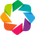

In [16]:
import holoviews as hv
hv.extension('bokeh')

# Holoviews + bokeh gives interactive zoom (wheel + box), pan, hover, reset and
# save in the figure toolbar -- no extra Jupyter extension required. We render
# in EPSG:3031 directly (no cartopy), since rasterise_anomaly already returns
# the image on that grid. Pixel coords are meters from the South Pole.

def hv_anomaly_image(img, extent, vmax, label='velocity anomaly (m yr⁻¹)',
                    title='', width=720, height=720):
    """Wrap a (img, extent) pair into a hv.Image with bokeh tools."""
    # hv.Image expects bounds=(left, bottom, right, top). origin='lower' raster
    # is in image-coords with row 0 = south, so flipud to put top at index 0.
    bounds = (extent[0], extent[2], extent[1], extent[3])
    return hv.Image(img[::-1, :], bounds=bounds, label=title).opts(
        cmap='RdBu_r', clim=(-vmax, vmax), colorbar=True,
        width=width, height=height,
        xlabel='x  (m, EPSG:3031)', ylabel='y  (m, EPSG:3031)',
        clabel=label, tools=['hover'],
        active_tools=['box_zoom', 'pan'], data_aspect=1,
        title=title,
    )


In [17]:
# Build one image per year, lazily wrapped into a HoloMap. Holoviews shows a
# year slider above the figure; the bokeh toolbar (wheel-zoom, box-zoom, pan,
# hover, reset, save) sits along the right edge of the plot.
slider_years = [y for y in ANNUAL_YEARS if y != BASELINE_YEAR and y in RASTER_BY_YEAR]

def _frame(year):
    img, extent = RASTER_BY_YEAR[year]
    n = int(np.sum(~np.isnan(img)))
    span = VEL_ANNUAL[year]['span']
    return hv_anomaly_image(
        img, extent, VMAX_PLOT1,
        label=f'velocity anomaly vs {BASELINE_YEAR}–{BASELINE_YEAR+1}  (m yr⁻¹)',
        title=f'Antarctic grounding-zone velocity anomaly  '
              f'{span[0]}–{span[1]}   ({n:,} cells)',
    )

hmap = hv.HoloMap({y: _frame(y) for y in slider_years}, kdims='year')
hmap


## 8. Plot 2 — Master grounding zone, 1995–2001 vs 2020–2022

Single static figure. Same diverging colormap; vmax fixed at the 95th percentile of |master_anomaly|.

In [ ]:
VMAX_PLOT2 = float(np.nanpercentile(np.abs(MASTER_ANOMALY), 95)) if MASTER_ANOMALY.size else 1.0
print(f'master ±{VMAX_PLOT2:.0f} m/yr scale')

img2, extent2 = rasterise_anomaly(MASTER_CELLS, MASTER_ANOMALY, pixel_m=1000.0)

hv_anomaly_image(
    img2, extent2, VMAX_PLOT2,
    label=f'velocity change  {PLOT2_EPOCH_RECENT} − {PLOT2_EPOCH_BASELINE}  (m yr⁻¹)',
    title=f'Antarctic master grounding zone   '
          f'{PLOT2_EPOCH_BASELINE} → {PLOT2_EPOCH_RECENT}   '
          f'({MASTER_CELLS.size:,} cells)',
    width=820, height=780,
)


### Notes

- The grounding-zone definition is purely morton-derived: `linestring_coverage` rasterises each polyline to order-16 cells, `morton_buffer(k=5)` adds a ~500 m halo, and `morton_clip_order` re-aggregates to whatever match order the velocity source needs. No KD-tree, no per-pixel search.
- Annual velocity files are ~21 NetCDFs at a few hundred MB each — the first run will take a while; the `download_if_missing` shortcut makes re-runs essentially free.
- Both plots rasterise their (sparse) anomaly arrays to a continental EPSG:3031 grid before `imshow` — at the orders involved, this is dramatically faster than rendering each cell as a polygon, and visually equivalent at continental zoom levels.